# Milestone 2 — Inferential & Predictive Analysis
### Insurance, Access, and Cost: A Two-Lens Analysis of Diabetes Care in New England

**ALY 6150 — Group Project (Anh Diep Chung, Tran Trinh, Priyanka Srinivas)**

This workbook extends the Milestone 1 descriptive report with the analyses required for Milestone 2: hypothesis tests, odds-ratio / relative-risk tables, rates by group, an external data merge, a map, and two models — a **logistic regression** for missed care due to cost (inferential) and a **logistic / LASSO / gradient-boosting** comparison for high-spender status (predictive).

All logic lives in `src/milestone2_analysis.py`; this notebook calls it and narrates the results.

> **Data note.** The teammate's expanded cleaning code (`src/brfss_cleaning.py`) supports 11 states + an SDOH module, but the processed CSV has not yet been regenerated and the raw `.XPT` files are not in the repo. This milestone therefore uses the available Milestone 1 cleaned data: **national MEPS (n=812)** and **6-state New England BRFSS (n=1,983)**.

> **Time-series note.** For the trend chart only, `src/brfss_trend.py` downloads the raw BRFSS annual files (2019–2023) and recomputes the missed-care rate; those large `.XPT` files are gitignored.

## 0. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

%load_ext autoreload
%autoreload 2

import pandas as pd
from IPython.display import Image, display

import src.milestone2_analysis as m2

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

In [2]:
# Load the Milestone 1 cleaned files and add the Milestone 2 derived variables.
meps  = m2.engineer_meps_features(m2.load_meps())
brfss = m2.engineer_brfss_features(m2.load_brfss())
print(f"MEPS : {len(meps):,} rows, {meps.shape[1]} columns")
print(f"BRFSS: {len(brfss):,} rows, {brfss.shape[1]} columns")

MEPS : 812 rows, 37 columns
BRFSS: 1,983 rows, 49 columns


## 1. Additional feature engineering
New Milestone-2 variables created on top of the Milestone 1 features:

| Variable | Dataset | Definition |
|---|---|---|
| `log_total_expense` | MEPS | log(1 + total medical expense) — tames the right skew |
| `multimorbid` | MEPS | 1 if comorbidity_count ≥ 2 |
| `any_acute_util` | MEPS | 1 if any ER visit **or** inpatient stay |
| `race_group` | BRFSS | race collapsed to 4 stable levels for modeling |
| `multimorbid` | BRFSS | 1 if comorbidity_count ≥ 3 |

In [3]:
display(meps[["total_medical_expense","log_total_expense","comorbidity_count","multimorbid","any_acute_util"]].head())
display(brfss[["race_ethnicity","race_group","comorbidity_count","multimorbid"]].head())

,total_medical_expense,log_total_expense,comorbidity_count,multimorbid,any_acute_util
0,646.0,6.472346,0.0,0,0
1,13.0,2.639057,1.0,0,0
2,1675.0,7.424165,2.0,1,0
3,0.0,0.000000,0.0,0,0
4,4393.0,8.387995,2.0,1,1


,race_ethnicity,race_group,comorbidity_count,multimorbid
0,NH White,NH White,3.0,1
1,Hispanic,Hispanic,3.0,1
2,NH White,NH White,3.0,1
3,NH White,NH White,3.0,1
4,NH White,NH White,2.0,0


## 2. External data merge — state-level Census context
To place the six New England states in socioeconomic context we merge a curated table of 2023 U.S. Census / ACS estimates (population, median household income, overall uninsured rate). This is the Milestone-2 "merge an additional dataset" requirement.

*(Values are approximate published ACS 2023 estimates — verify exact figures at data.census.gov for the final references page.)*

In [4]:
display(m2.STATE_CONTEXT)

# State-level BRFSS rates joined to the external context — used for the map
# and as an ecological check on whether state affluence tracks missed care.
state_summary = (brfss.groupby("state_name")
    .agg(missed_care_rate=("missed_care_cost","mean"),
         low_income_share=("is_low_income","mean"),
         n=("missed_care_cost","size"))
    .reset_index()
    .merge(m2.STATE_CONTEXT, on="state_name"))
state_summary["missed_care_rate"] = (state_summary["missed_care_rate"]*100).round(1)
state_summary

,state_name,state_abbr,population_2023,median_hh_income_2023,uninsured_rate_pct_2023
0,Connecticut,CT,3617000,93760,5.5
1,Maine,ME,1402000,73733,5.7
2,Massachusetts,MA,7001000,101341,2.4
3,New Hampshire,NH,1403000,96838,5.8
4,Rhode Island,RI,1096000,84972,4.0
5,Vermont,VT,647000,81211,3.8


,state_name,missed_care_rate,low_income_share,n,state_abbr,population_2023,median_hh_income_2023,uninsured_rate_pct_2023
0,Connecticut,8.5,0.316923,399,CT,3617000,93760,5.5
1,Maine,7.0,0.420561,504,ME,1402000,73733,5.7
2,Massachusetts,10.1,0.369811,335,MA,7001000,101341,2.4
3,New Hampshire,11.7,0.295082,224,NH,1403000,96838,5.8
4,Rhode Island,12.6,0.428571,270,RI,1096000,84972,4.0
5,Vermont,6.0,0.256881,251,VT,647000,81211,3.8


## 3. Hypothesis tests
Six headline tests covering both datasets. Chi-square for categorical associations, Mann-Whitney U / Kruskal-Wallis for skewed continuous comparisons (same test family as Milestone 1).

In [5]:
tests = m2.run_hypothesis_tests(meps, brfss)
tests

,Dataset,Null hypothesis,Test,Statistic,p-value,Significant (a=0.05)
0,BRFSS,Missed care due to cost is independent of insu...,Chi-square,chi2=99.5 (df=1),<0.001,Yes
1,BRFSS,Missed-care rate is equal across the six New E...,Chi-square,chi2=12.0 (df=5),0.035,Yes
2,BRFSS,Comorbidity count is the same for those who di...,Mann-Whitney U,"U=143,510",0.019,Yes
3,MEPS,High-spender status is independent of insuranc...,Chi-square,chi2=26.1 (df=2),<0.001,Yes
4,MEPS,Total medical expense is equal across insuranc...,Kruskal-Wallis,H=81.9,<0.001,Yes
5,MEPS,Total expense is the same with vs without acut...,Mann-Whitney U,"U=33,700",<0.001,Yes


**Reading the tests.** Every null hypothesis is rejected at α = 0.05. Missed care is strongly associated with insurance status (χ² ≈ 99.5, p < 0.001) and varies across states (p = 0.035). On the MEPS side, high-spender status and total expense both differ sharply by insurance type and by acute utilization (all p < 0.001).

## 4. Odds ratio & relative risk
### 4a. 2×2 table — uninsured → missed care (BRFSS)

In [6]:
or_rr = m2.or_rr_2x2(brfss, "uninsured", "missed_care_cost")
or_rr

,Group,Event (yes),No event,n,Risk
0,uninsured=exposed,26,28,54,48.1%
1,uninsured=unexposed,145,1706,1851,7.8%
2,Odds ratio (OR),,,,10.93 (95% CI 6.24-19.13)
3,Relative risk (RR),,,,6.15 (95% CI 4.47-8.45)


Uninsured diabetic adults have **~11× the odds** (OR = 10.93, 95% CI 6.24–19.13) and **~6× the risk** (RR = 6.15, 95% CI 4.47–8.45) of missing needed care — matching the Milestone 1 figures (the 6.1× rate comparison) and reconciling why the OR exceeds the RR when the outcome is common in the exposed group.

### 4b. Unadjusted odds ratios for each candidate predictor

In [7]:
crude = m2.unadjusted_or_panel(brfss, "missed_care_cost",
    ["uninsured","is_low_income","poor_health","multimorbid","race_group","state_name"])
crude

,Predictor,OR (95% CI),p-value
0,uninsured,10.93 (6.24-19.13),<0.001
1,is_low_income,2.74 (1.94-3.86),<0.001
2,poor_health,2.33 (1.70-3.19),<0.001
3,multimorbid,1.21 (0.89-1.65),0.229
4,C(race_group)[T.NH Black],0.47 (0.22-0.98),0.045
5,C(race_group)[T.NH White],0.30 (0.20-0.45),<0.001
6,C(race_group)[T.Other],0.51 (0.27-0.98),0.043
7,C(state_name)[T.Maine],0.80 (0.49-1.32),0.386
8,C(state_name)[T.Massachusetts],1.21 (0.74-2.00),0.449
9,C(state_name)[T.New Hampshire],1.42 (0.83-2.43),0.205


## 5. Rates by group (with 95% CIs)
Missed-care rates with Wilson confidence intervals — a clean "rates by group" tabulation.

In [8]:
display(m2.rate_by_group(brfss, "missed_care_cost", "state_name"))
display(m2.rate_by_group(brfss, "missed_care_cost", "income_tier"))

,state_name,n,events,Rate,95% CI
0,Rhode Island,270,34,12.6%,9.2%-17.1%
1,New Hampshire,223,26,11.7%,8.1%-16.5%
2,Massachusetts,335,34,10.1%,7.4%-13.8%
3,Connecticut,399,34,8.5%,6.2%-11.7%
4,Maine,502,35,7.0%,5.1%-9.5%
5,Vermont,248,15,6.0%,3.7%-9.7%


,income_tier,n,events,Rate,95% CI
0,<$25K,391,54,13.8%,10.7%-17.6%
1,$25-50K,381,48,12.6%,9.6%-16.3%
2,$50-75K,422,30,7.1%,5.0%-10.0%
3,$75K+,450,16,3.6%,2.2%-5.7%


Rhode Island (12.6%) and New Hampshire (11.7%) lead; Vermont is lowest (6.0%). The income gradient is steep — the lowest-income tier (13.8%) misses care nearly **4×** as often as the highest tier (3.6%).

## 6. Model 1 — Logistic regression: missed care due to cost (inferential)
Multivariable logistic regression, reported as adjusted odds ratios with 95% CIs and p-values. Predictors are kept lean (≈178 events) to avoid quasi-separation.

In [9]:
result, or_brfss, perf_brfss = m2.fit_missed_care_model(brfss)
print(f"Analytic n = {perf_brfss['n']:,}  |  events = {perf_brfss['events']}")
print(f"McFadden pseudo-R2 = {perf_brfss['pseudo_r2_mcfadden']:.3f}  |  in-sample AUC = {perf_brfss['in_sample_auc']:.3f}")
or_brfss[["Predictor","Adjusted OR","95% CI","p-value"]]

Analytic n = 1,596  |  events = 144
McFadden pseudo-R2 = 0.110  |  in-sample AUC = 0.729


,Predictor,Adjusted OR,95% CI,p-value
0,age_band_collapsed: 55-64,0.70,0.48-1.03,0.074
1,sex_label: Male,0.99,0.69-1.43,0.964
2,race_group (ref NH White): Hispanic,1.58,0.89-2.82,0.119
3,race_group (ref NH White): NH Black,1.28,0.58-2.82,0.543
4,race_group (ref NH White): Other,1.65,0.86-3.19,0.135
5,state_name (ref Massachusetts): Connecticut,0.74,0.41-1.35,0.330
6,state_name (ref Massachusetts): Maine,0.63,0.35-1.15,0.132
7,state_name (ref Massachusetts): New Hampshire,1.25,0.64-2.45,0.516
8,state_name (ref Massachusetts): Rhode Island,1.05,0.57-1.93,0.874
9,state_name (ref Massachusetts): Vermont,0.79,0.39-1.58,0.502


**Interpretation.** After adjusting for income, health, comorbidity, demographics, and state, lack of insurance remains the dominant driver — uninsured adults have **~9× the adjusted odds** of missing care (aOR ≈ 9.4, p < 0.001). Low income (aOR ≈ 2.0) and fair/poor health (aOR ≈ 1.9) are also independent predictors. This confirms the Milestone 1 expectation that insurance status would be the strongest predictor even after adjustment.

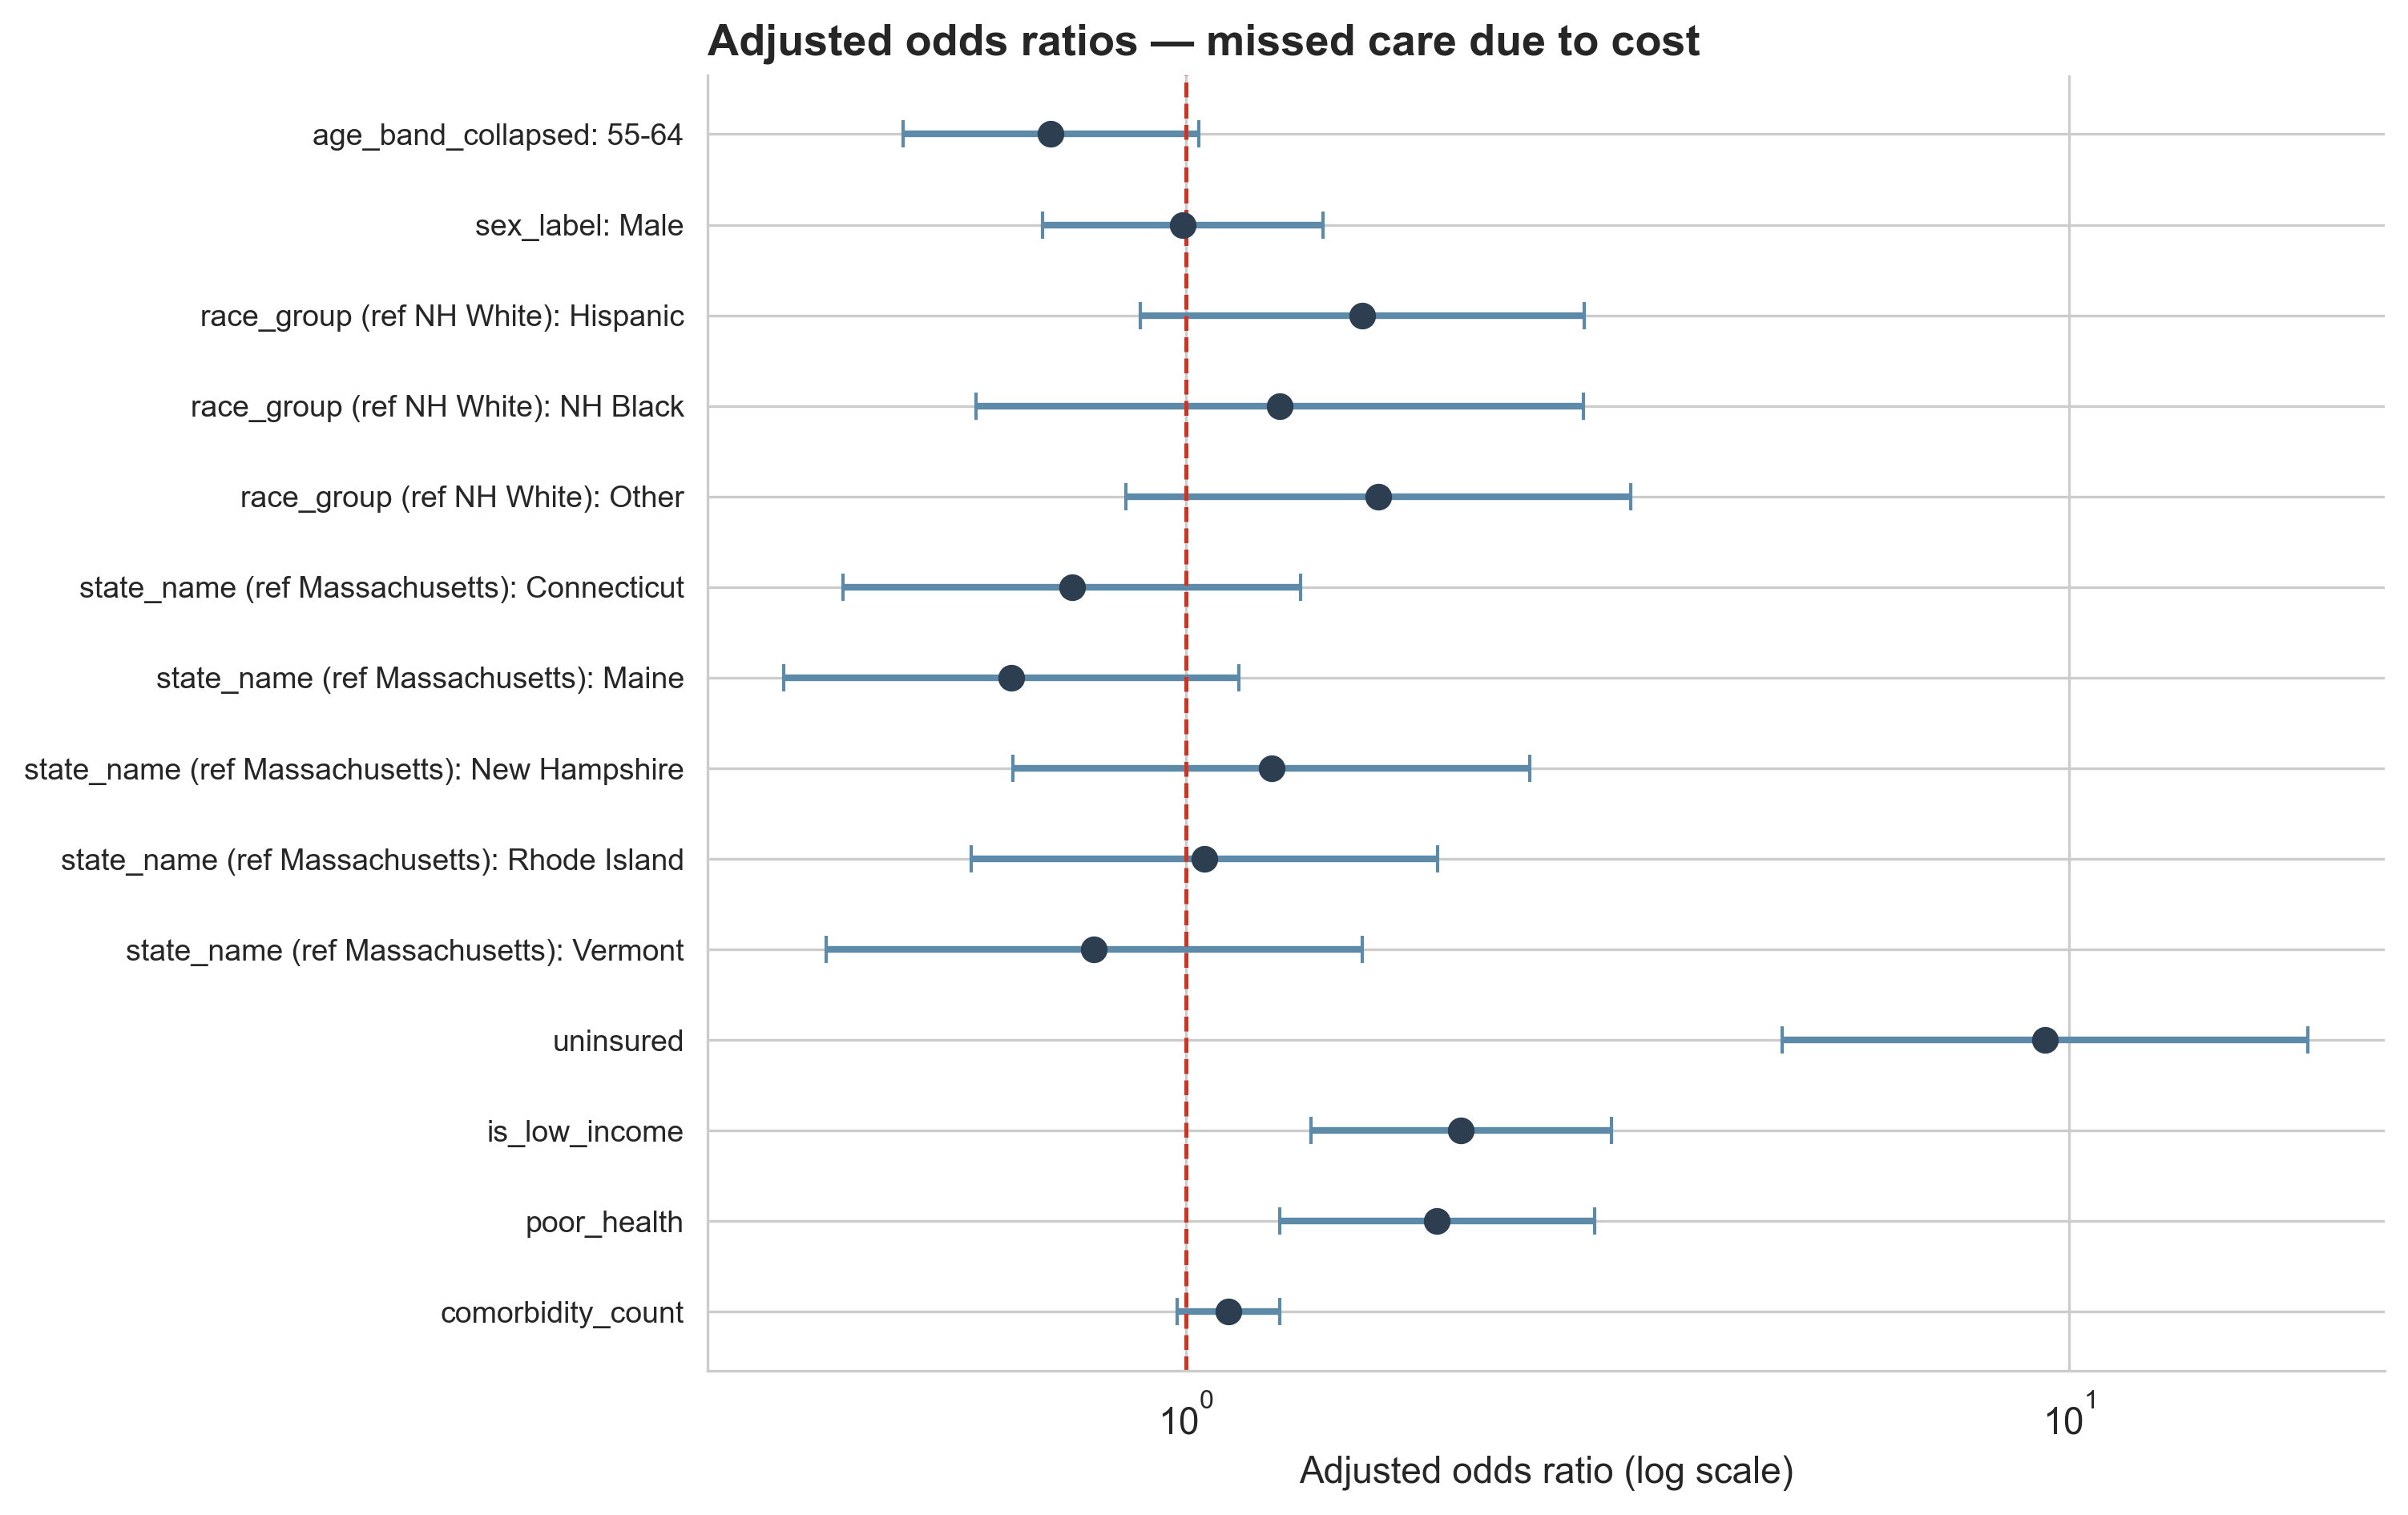

In [10]:
display(Image(filename="../outputs/figures/m2_forest_missed_care.png"))

## 7. Model 2 — Predicting high-spender status (predictive)
Three classifiers compared by 5-fold cross-validated ROC AUC: logistic regression, LASSO (L1) logistic, and gradient boosting. Predictors are utilization **counts** (not dollar amounts) to avoid leakage, since `high_spender` is derived from total dollars.

In [11]:
meps_res = m2.fit_high_spender_models(meps)
print(f"Analytic n = {meps_res['n']:,}  |  high spenders = {meps_res['events']}")
meps_res["cv_table"]

Analytic n = 809  |  high spenders = 203


,Model,CV ROC AUC (mean),CV ROC AUC (sd)
0,Logistic regression,0.831,0.031
1,LASSO logistic (L1),0.839,0.030
2,Gradient boosting,0.827,0.023


### 7a. Interpretable odds ratios (logistic)

In [12]:
meps_res["or_table"][["Predictor","Adjusted OR","95% CI","p-value"]]

,Predictor,Adjusted OR,95% CI,p-value
0,sex_label: Male,0.78,0.52-1.15,0.212
1,insurance_label (ref Any private): Public only,0.78,0.51-1.20,0.265
2,insurance_label (ref Any private): Uninsured,0.14,0.03-0.72,0.019
3,age,1.01,0.97-1.05,0.559
4,comorbidity_count,0.94,0.75-1.19,0.630
5,n_er_visits,1.15,0.93-1.42,0.208
6,n_inpatient_stays,5.78,3.58-9.33,<0.001
7,n_rx_fills,1.03,1.03-1.04,<0.001


### 7b. Held-out classification report + gradient-boosting importance

In [13]:
display(meps_res["report_table"])
display(meps_res["gb_importance"].head(8))

,precision,recall,f1-score,support
0,0.853,0.896,0.874,182.000
1,0.635,0.541,0.584,61.000
accuracy,0.807,0.807,0.807,0.807
macro avg,0.744,0.718,0.729,243.000
weighted avg,0.798,0.807,0.801,243.000


,Feature,Importance
0,n_rx_fills,0.538740
1,n_inpatient_stays,0.212266
2,age,0.107476
3,n_er_visits,0.049533
4,insurance_label_Uninsured,0.017328
5,race_ethnicity_NH White,0.016615
6,comorbidity_count,0.013597
7,race_ethnicity_NH Asian,0.010319


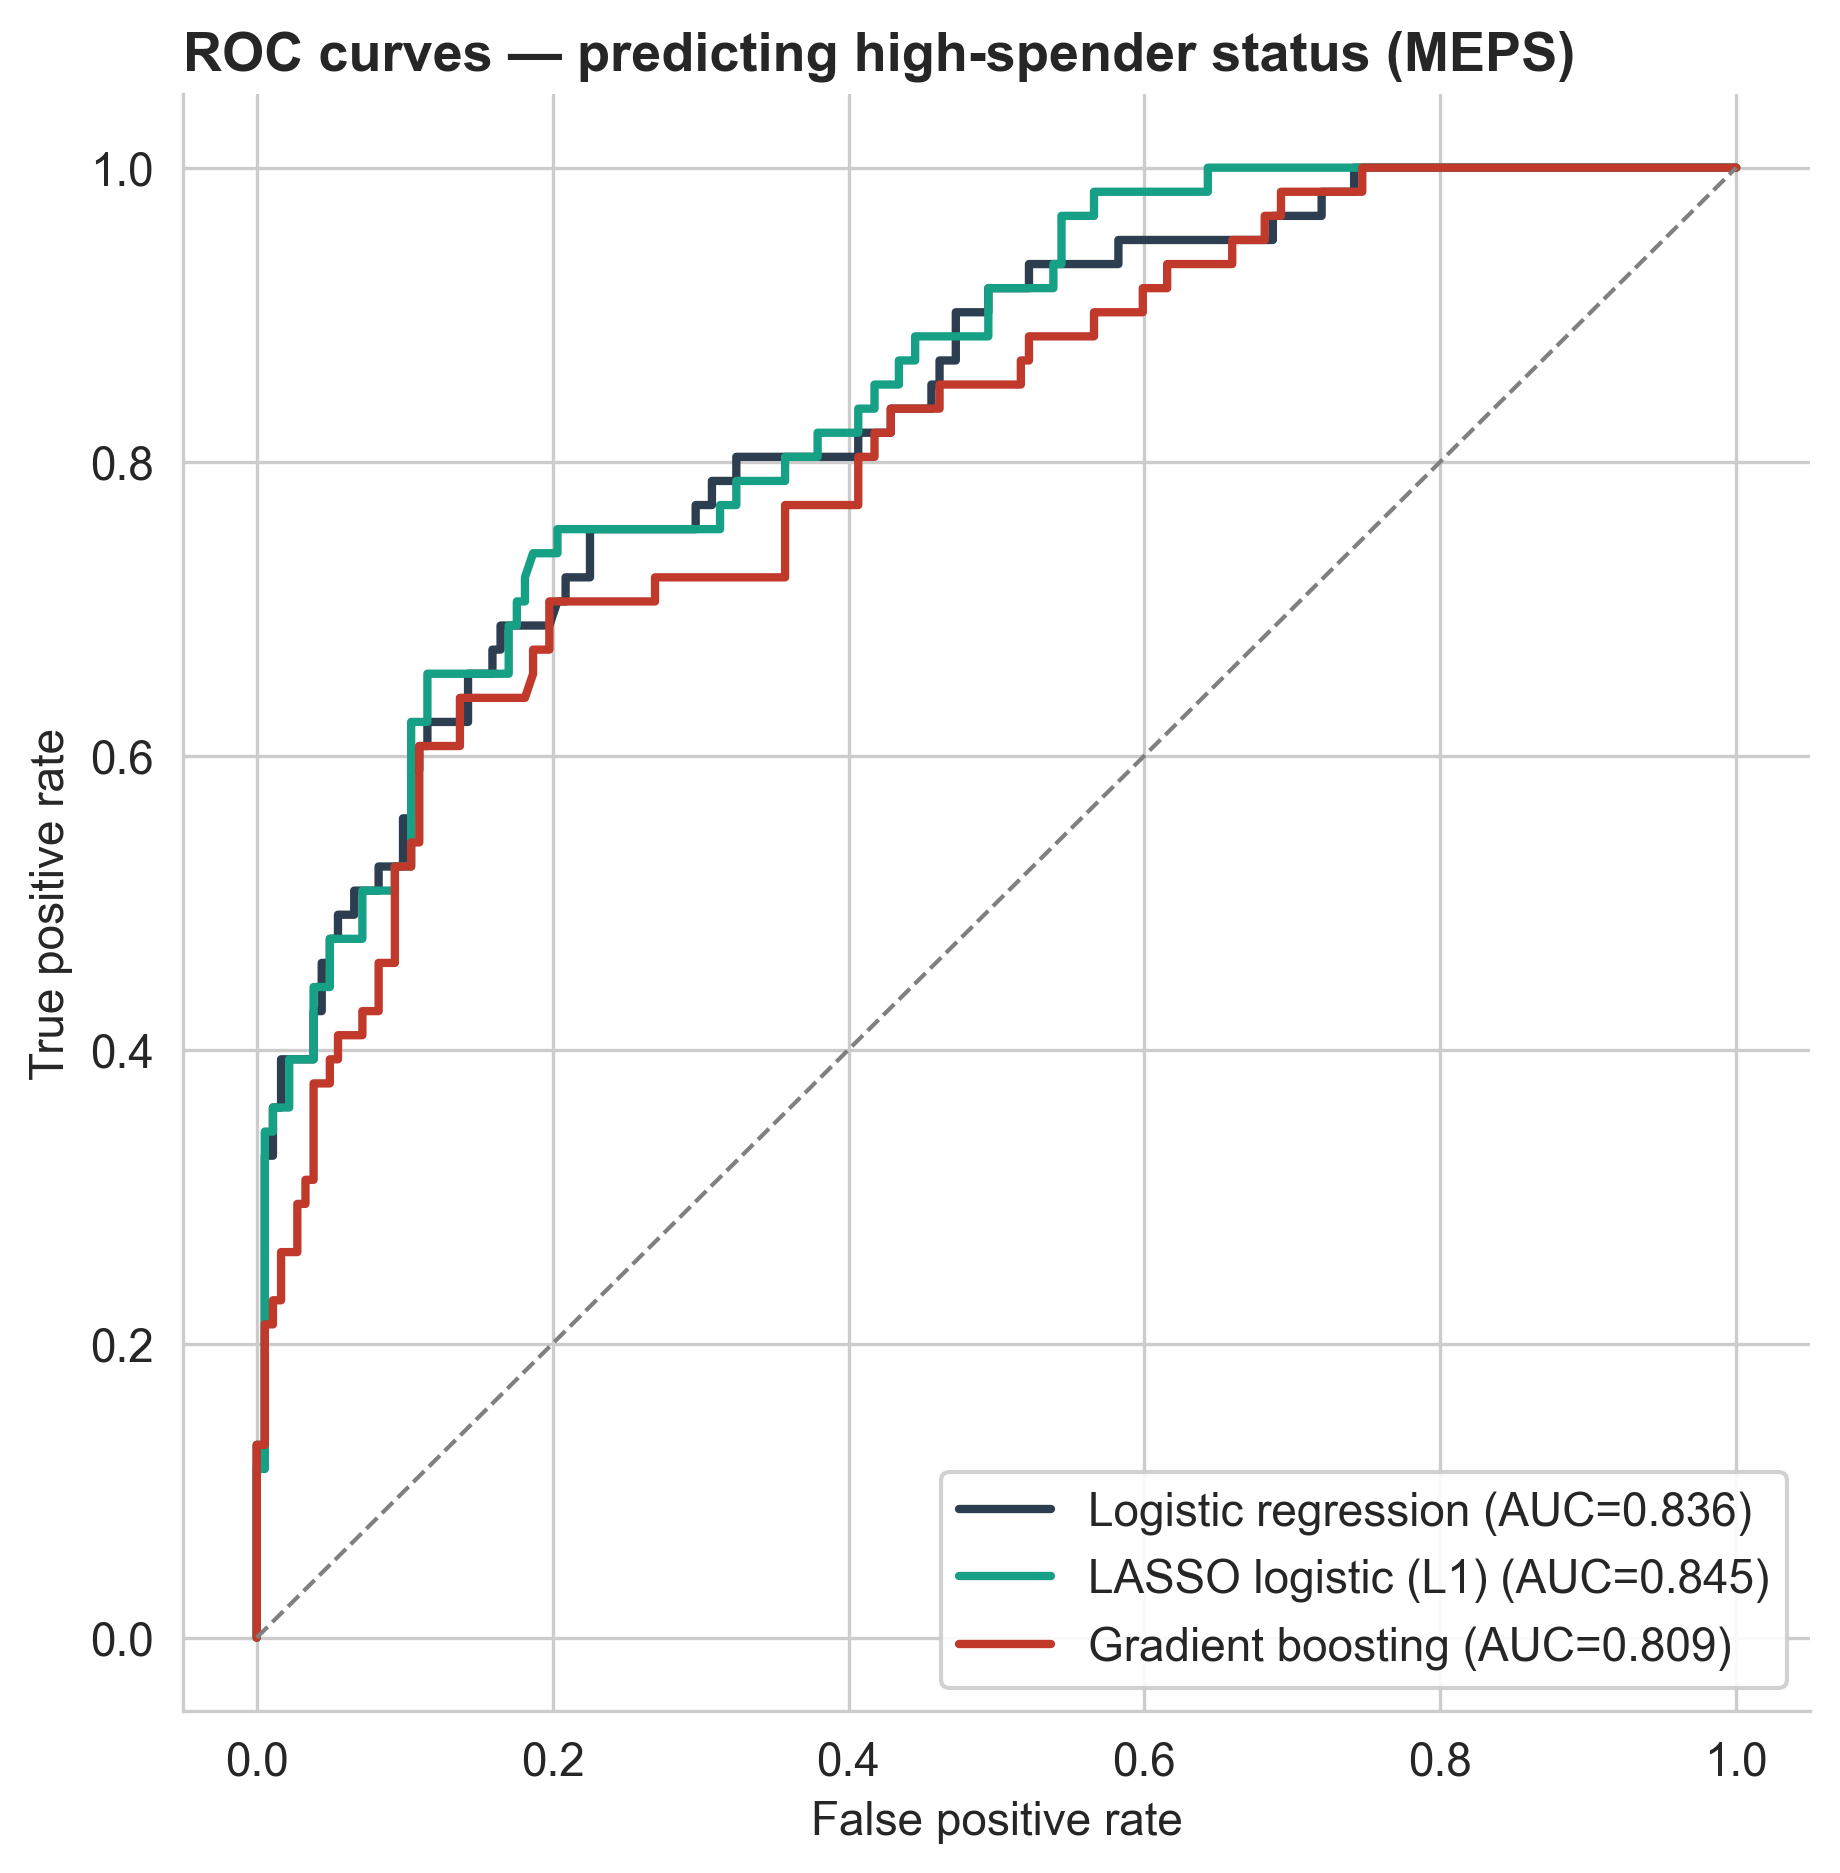

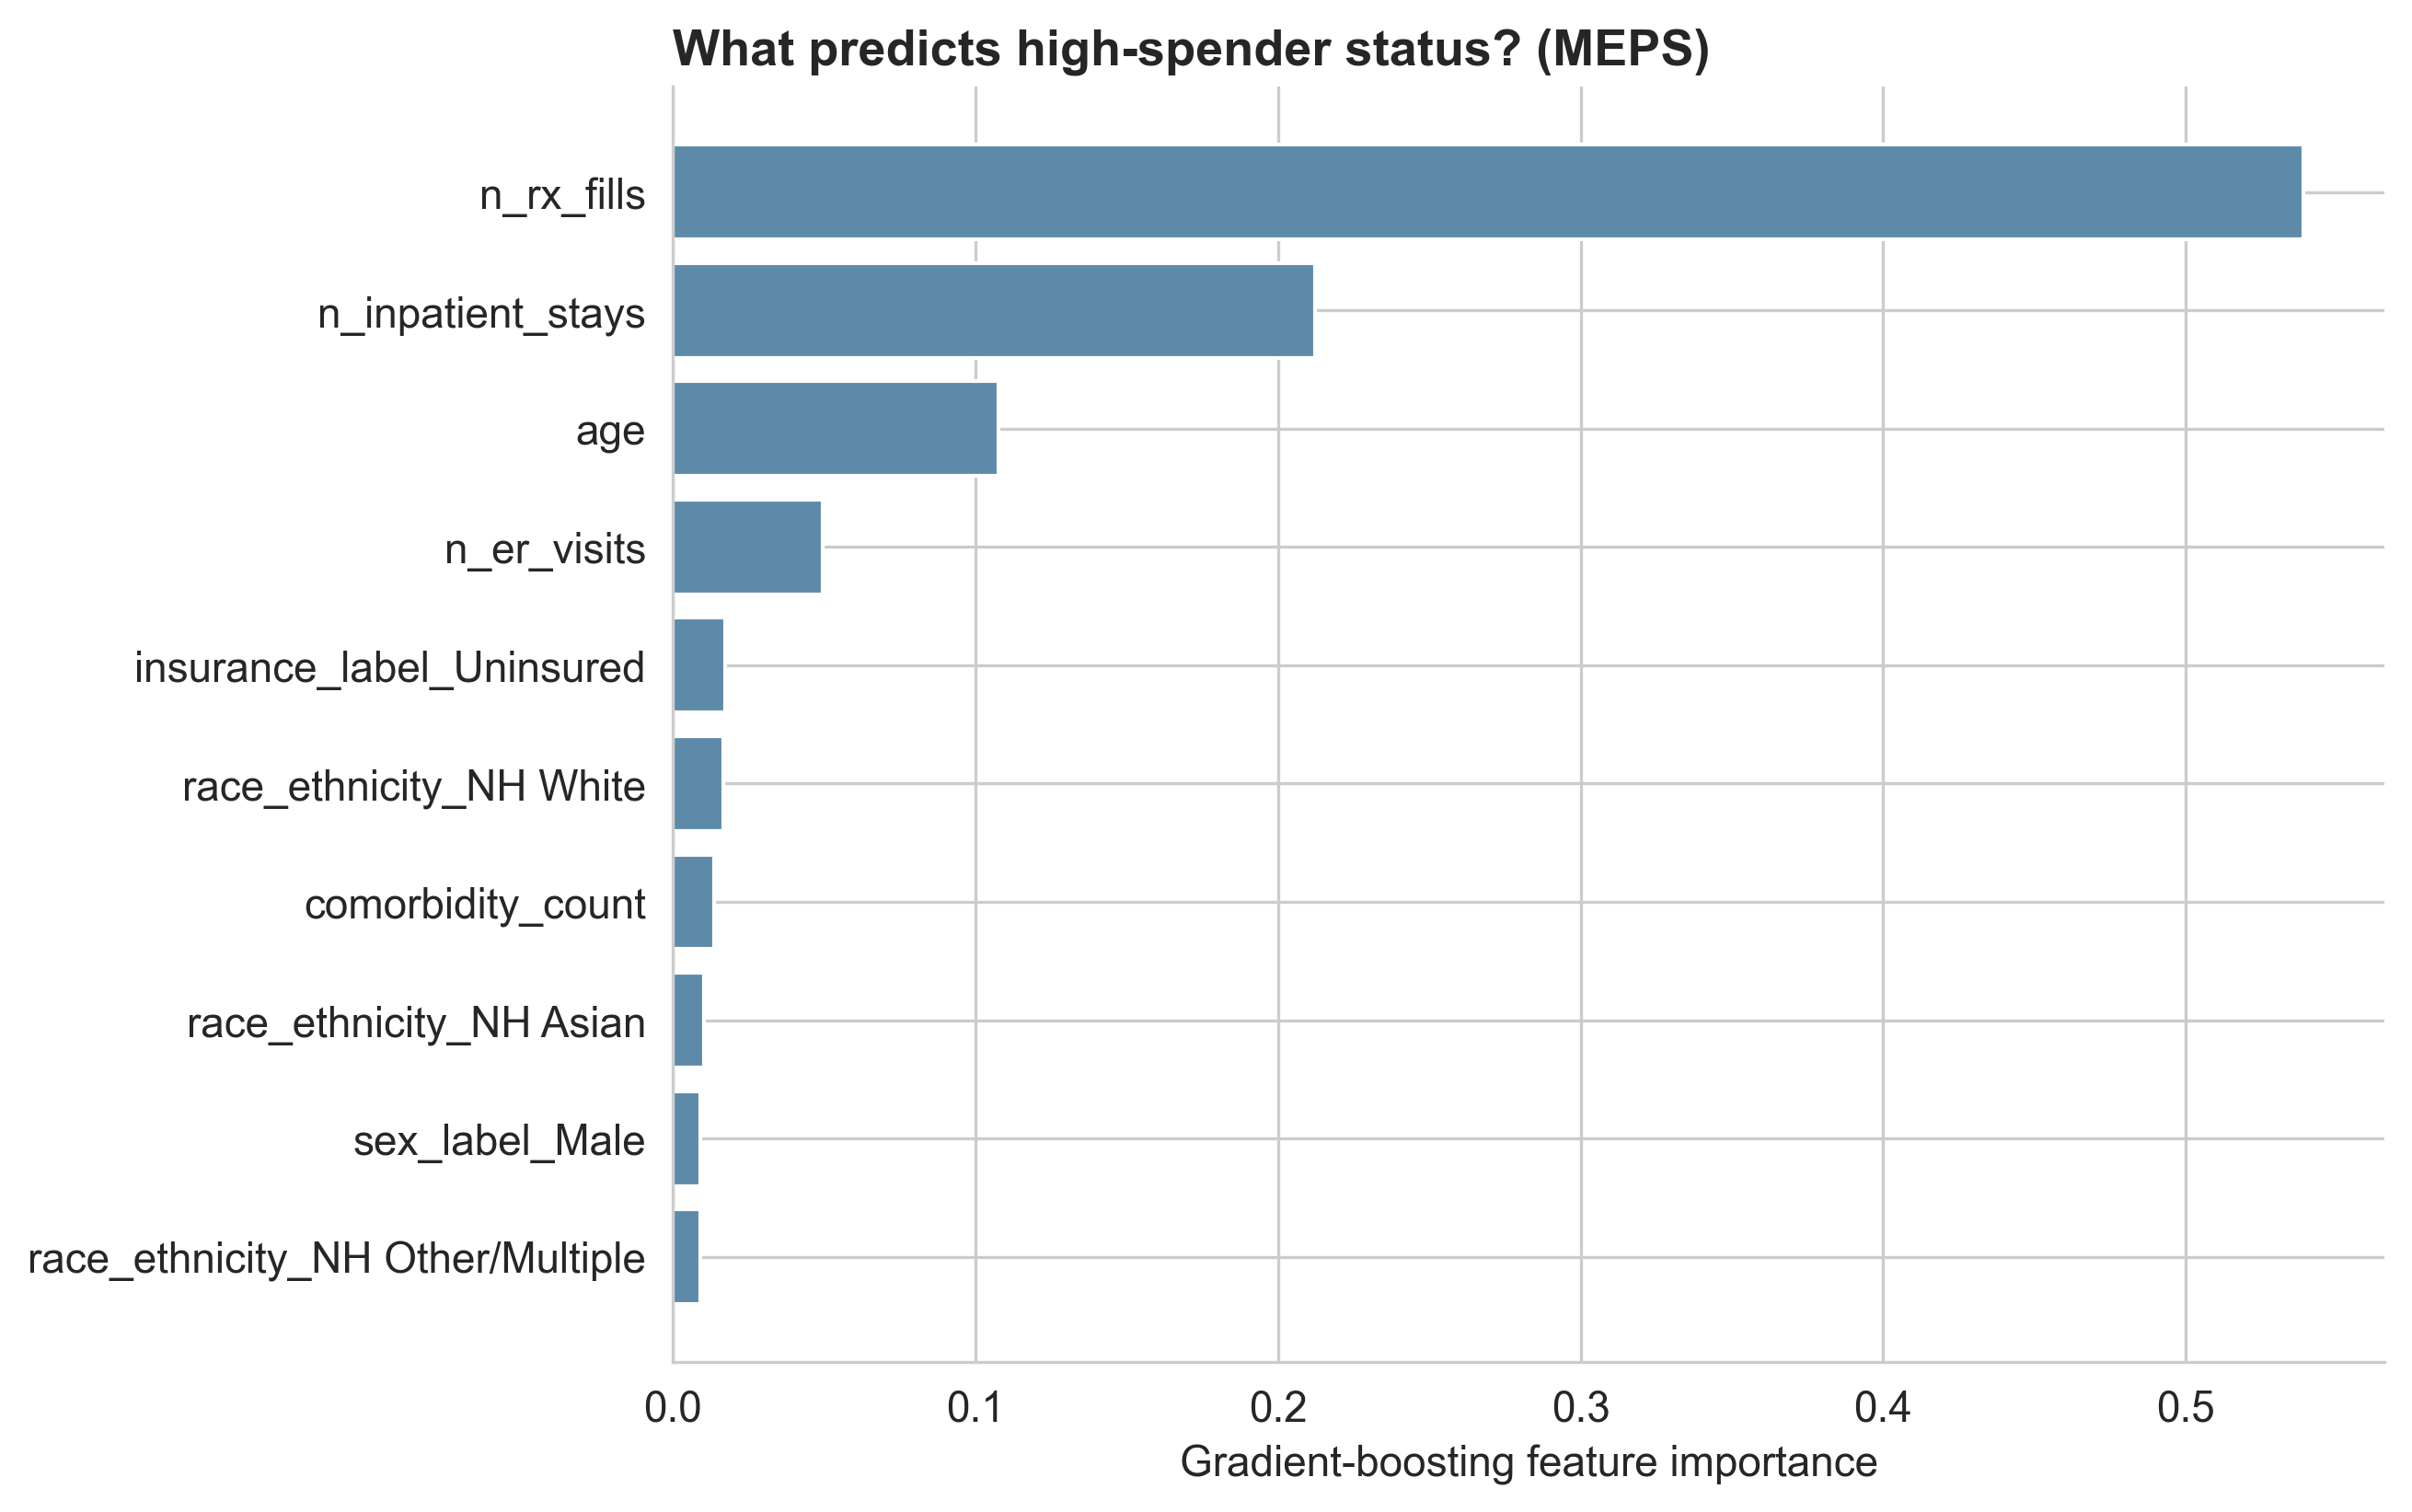

In [14]:
display(Image(filename="../outputs/figures/m2_roc_high_spender.png"))
display(Image(filename="../outputs/figures/m2_gb_importance.png"))

**Interpretation.** All three models discriminate well (CV AUC ≈ 0.83–0.84; LASSO marginally best), so the simple, interpretable logistic model is preferred. The strongest predictors are **prescription fills** and **inpatient stays** (adjusted OR ≈ 5.8 for inpatient stays), followed by age. Notably, once utilization is controlled, insurance type is no longer significant — utilization **mediates** the insurance–spending link seen in the unadjusted Milestone 1 tables. Uninsured adults are *less* likely to be high spenders (aOR ≈ 0.14), consistent with cost-driven under-use rather than better health.

## 8. Map — missed care due to cost by state
New England choropleth (BRFSS 2023).

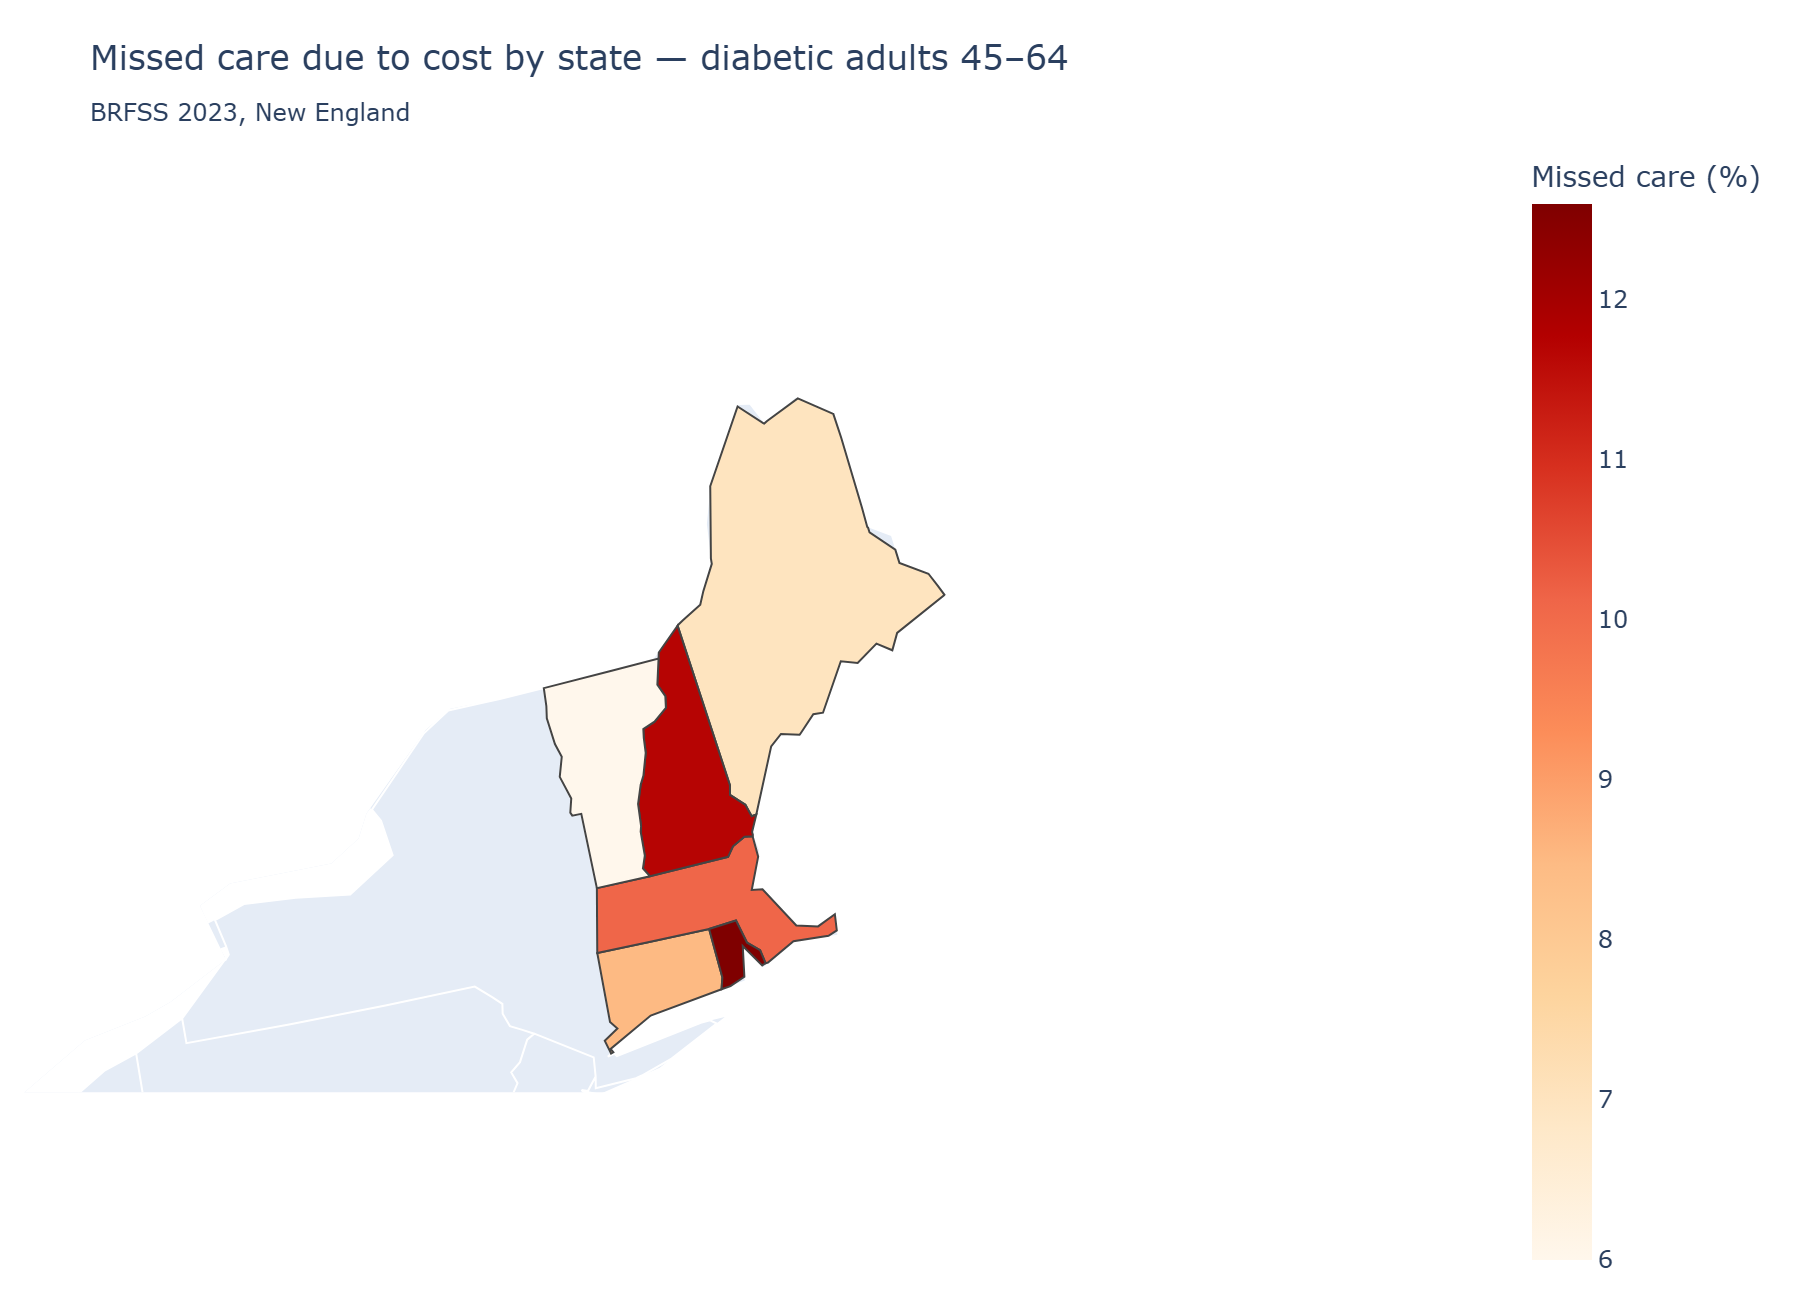

In [15]:
display(Image(filename="../outputs/figures/m2_map_missed_care_by_state.png"))

## 8b. Line charts — real time-series + model prediction curves
Two kinds of line chart. First a **genuine multi-year time-series**: the missed-care-due-to-cost rate among diabetic adults 45–64, built from the raw BRFSS annual files (2019–2023) with the same case definition as Milestone 1 — see `src/brfss_trend.py`. Then **model-based prediction curves** from the 2023 logistic models.

In [16]:
# Real time-series — yearly missed-care rate (US vs New England).
trend = pd.read_csv("../outputs/tables/m2_missed_care_trend.csv")
trend.pivot(index="year", columns="region", values="missed_care_rate_pct")

region,New England,United States
year,,
2019,12.15,16.86
2020,8.68,12.97
2021,8.33,11.72
2022,9.38,12.58
2023,9.00,12.95


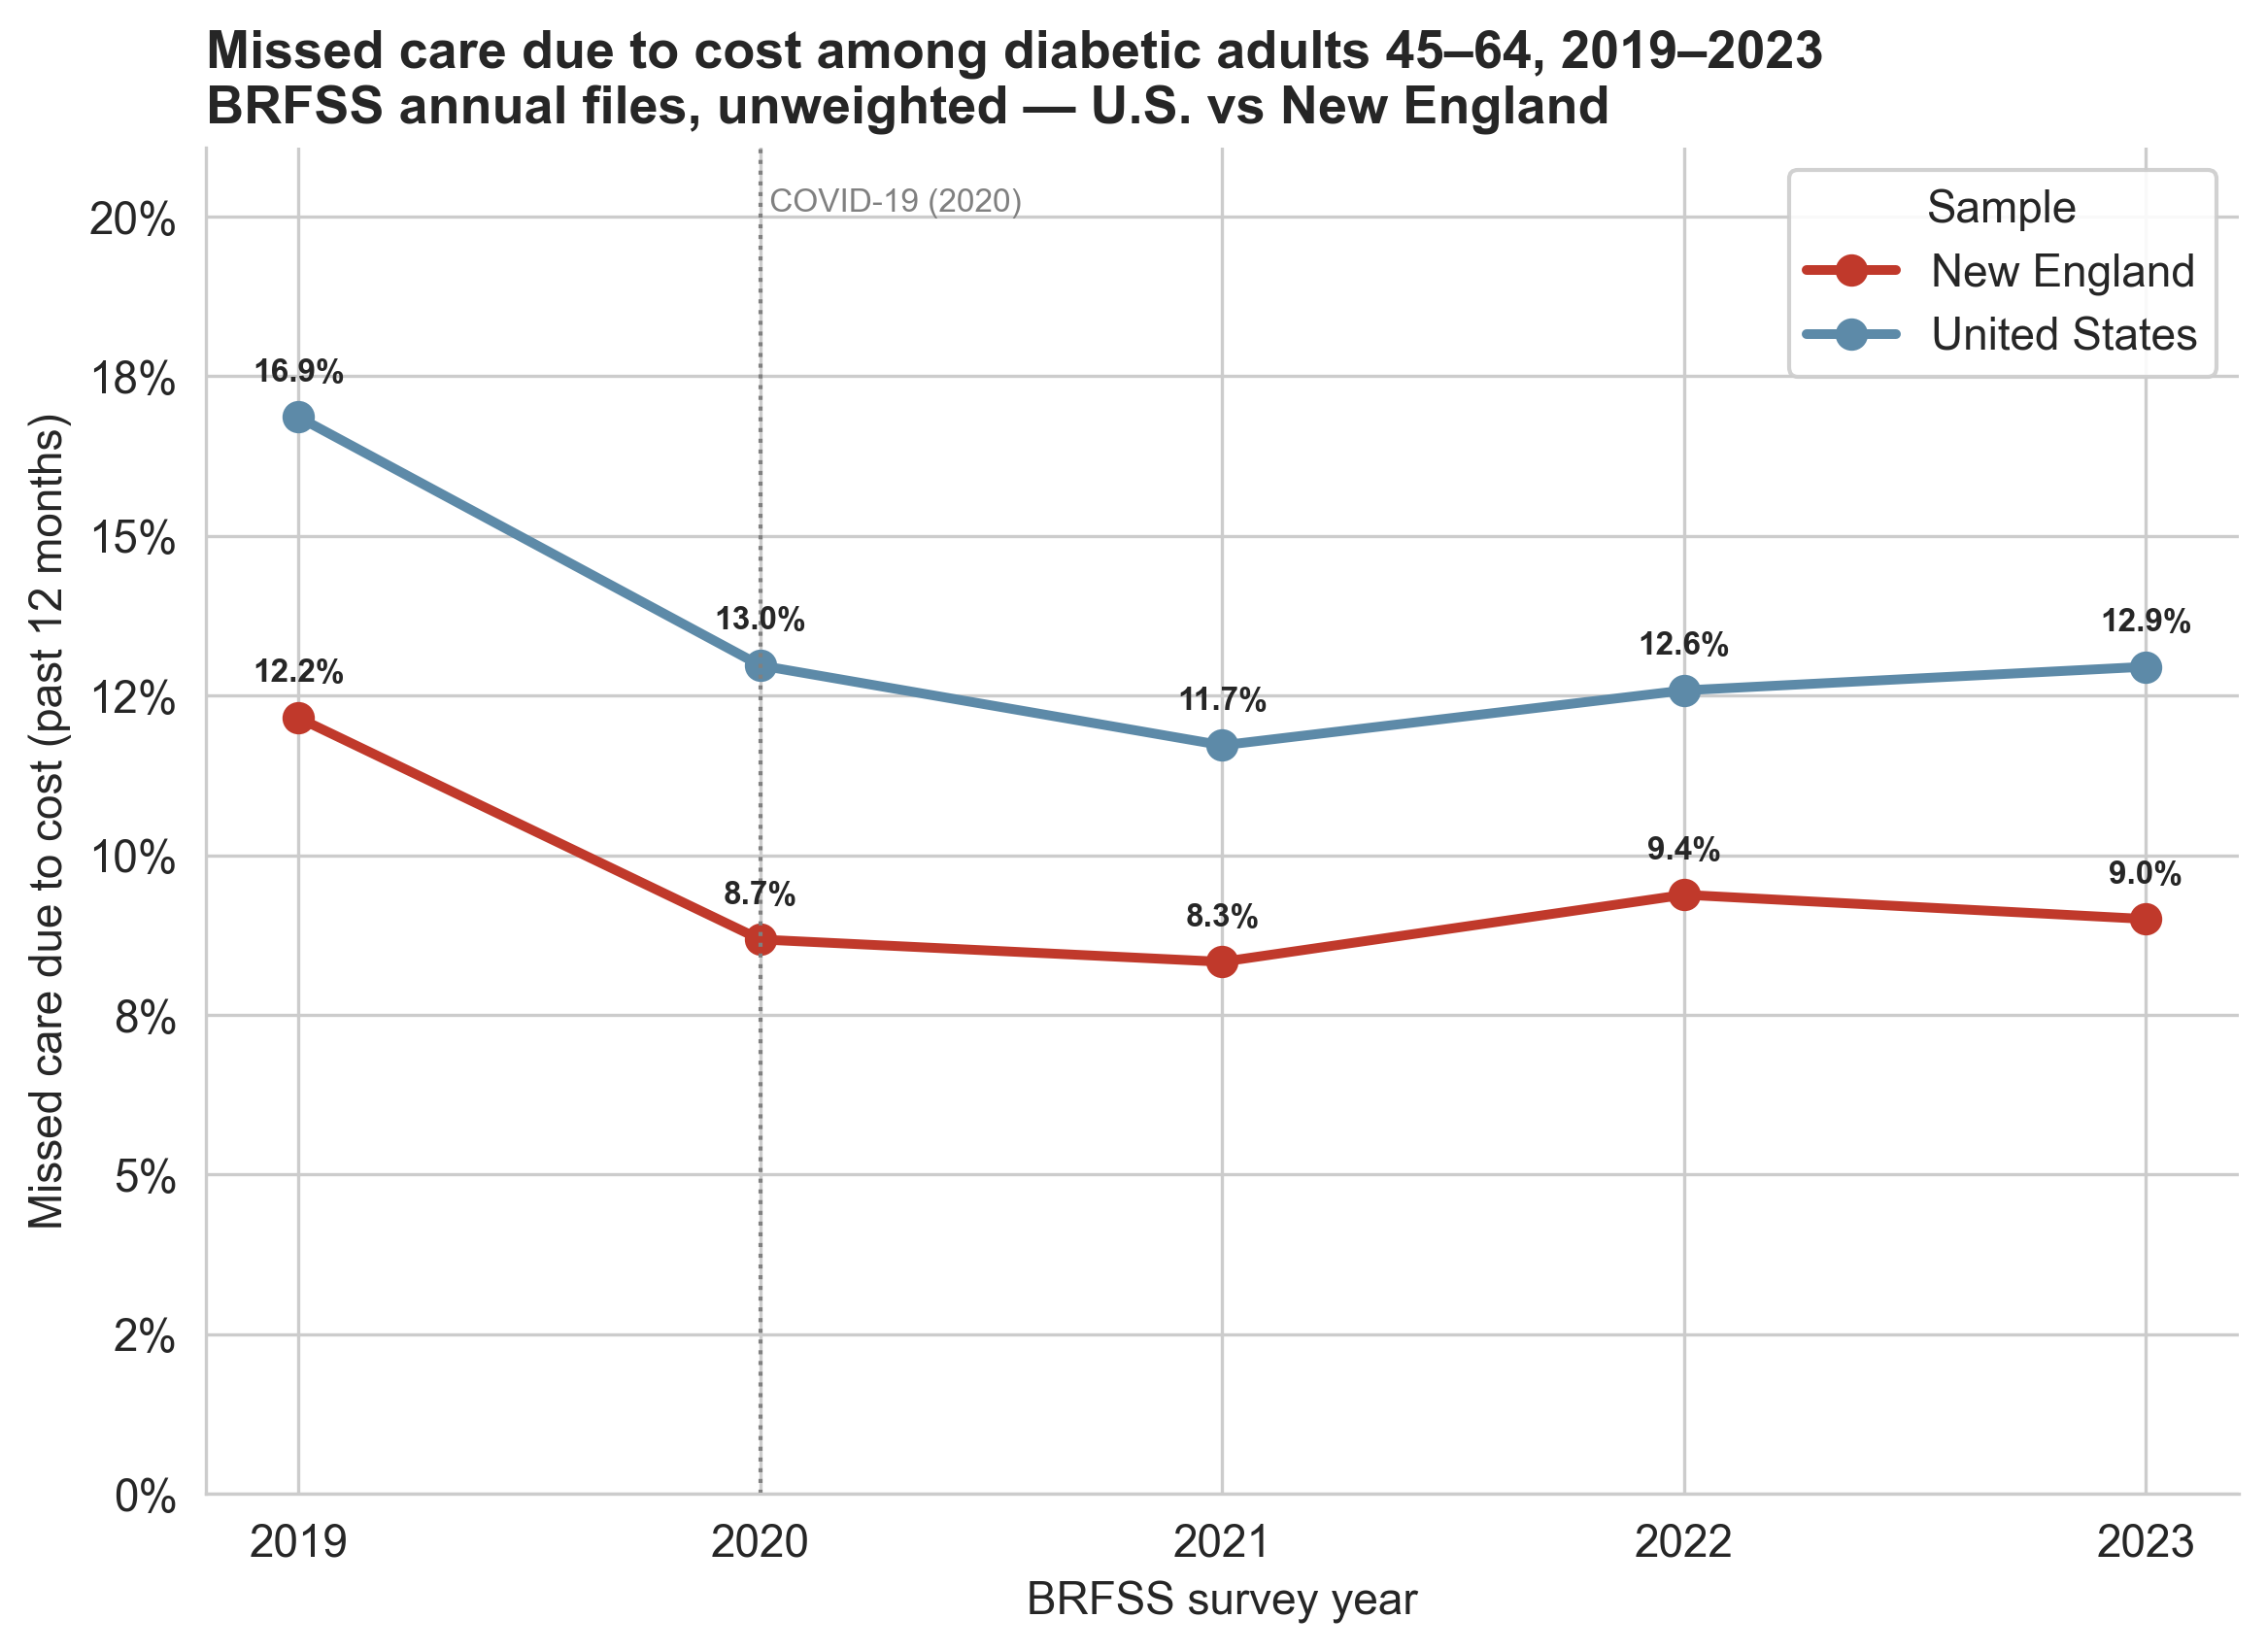

In [17]:
display(Image(filename="../outputs/figures/m2_trend_missed_care.png"))

**Reading the trend.** The cost barrier is persistent, not a one-year artifact: across 2019–2023 the New England rate stays consistently **below** the national rate for diabetic adults 45–64. The 2020 point should be read cautiously — BRFSS data collection was disrupted by the COVID-19 pandemic that year. The 2023 New England value reproduces the ~9% figure reported in Milestone 1, confirming the two pipelines agree.

### Model-based prediction curves
Predicted probabilities from the logistic models, showing *how much* the key predictors move risk.

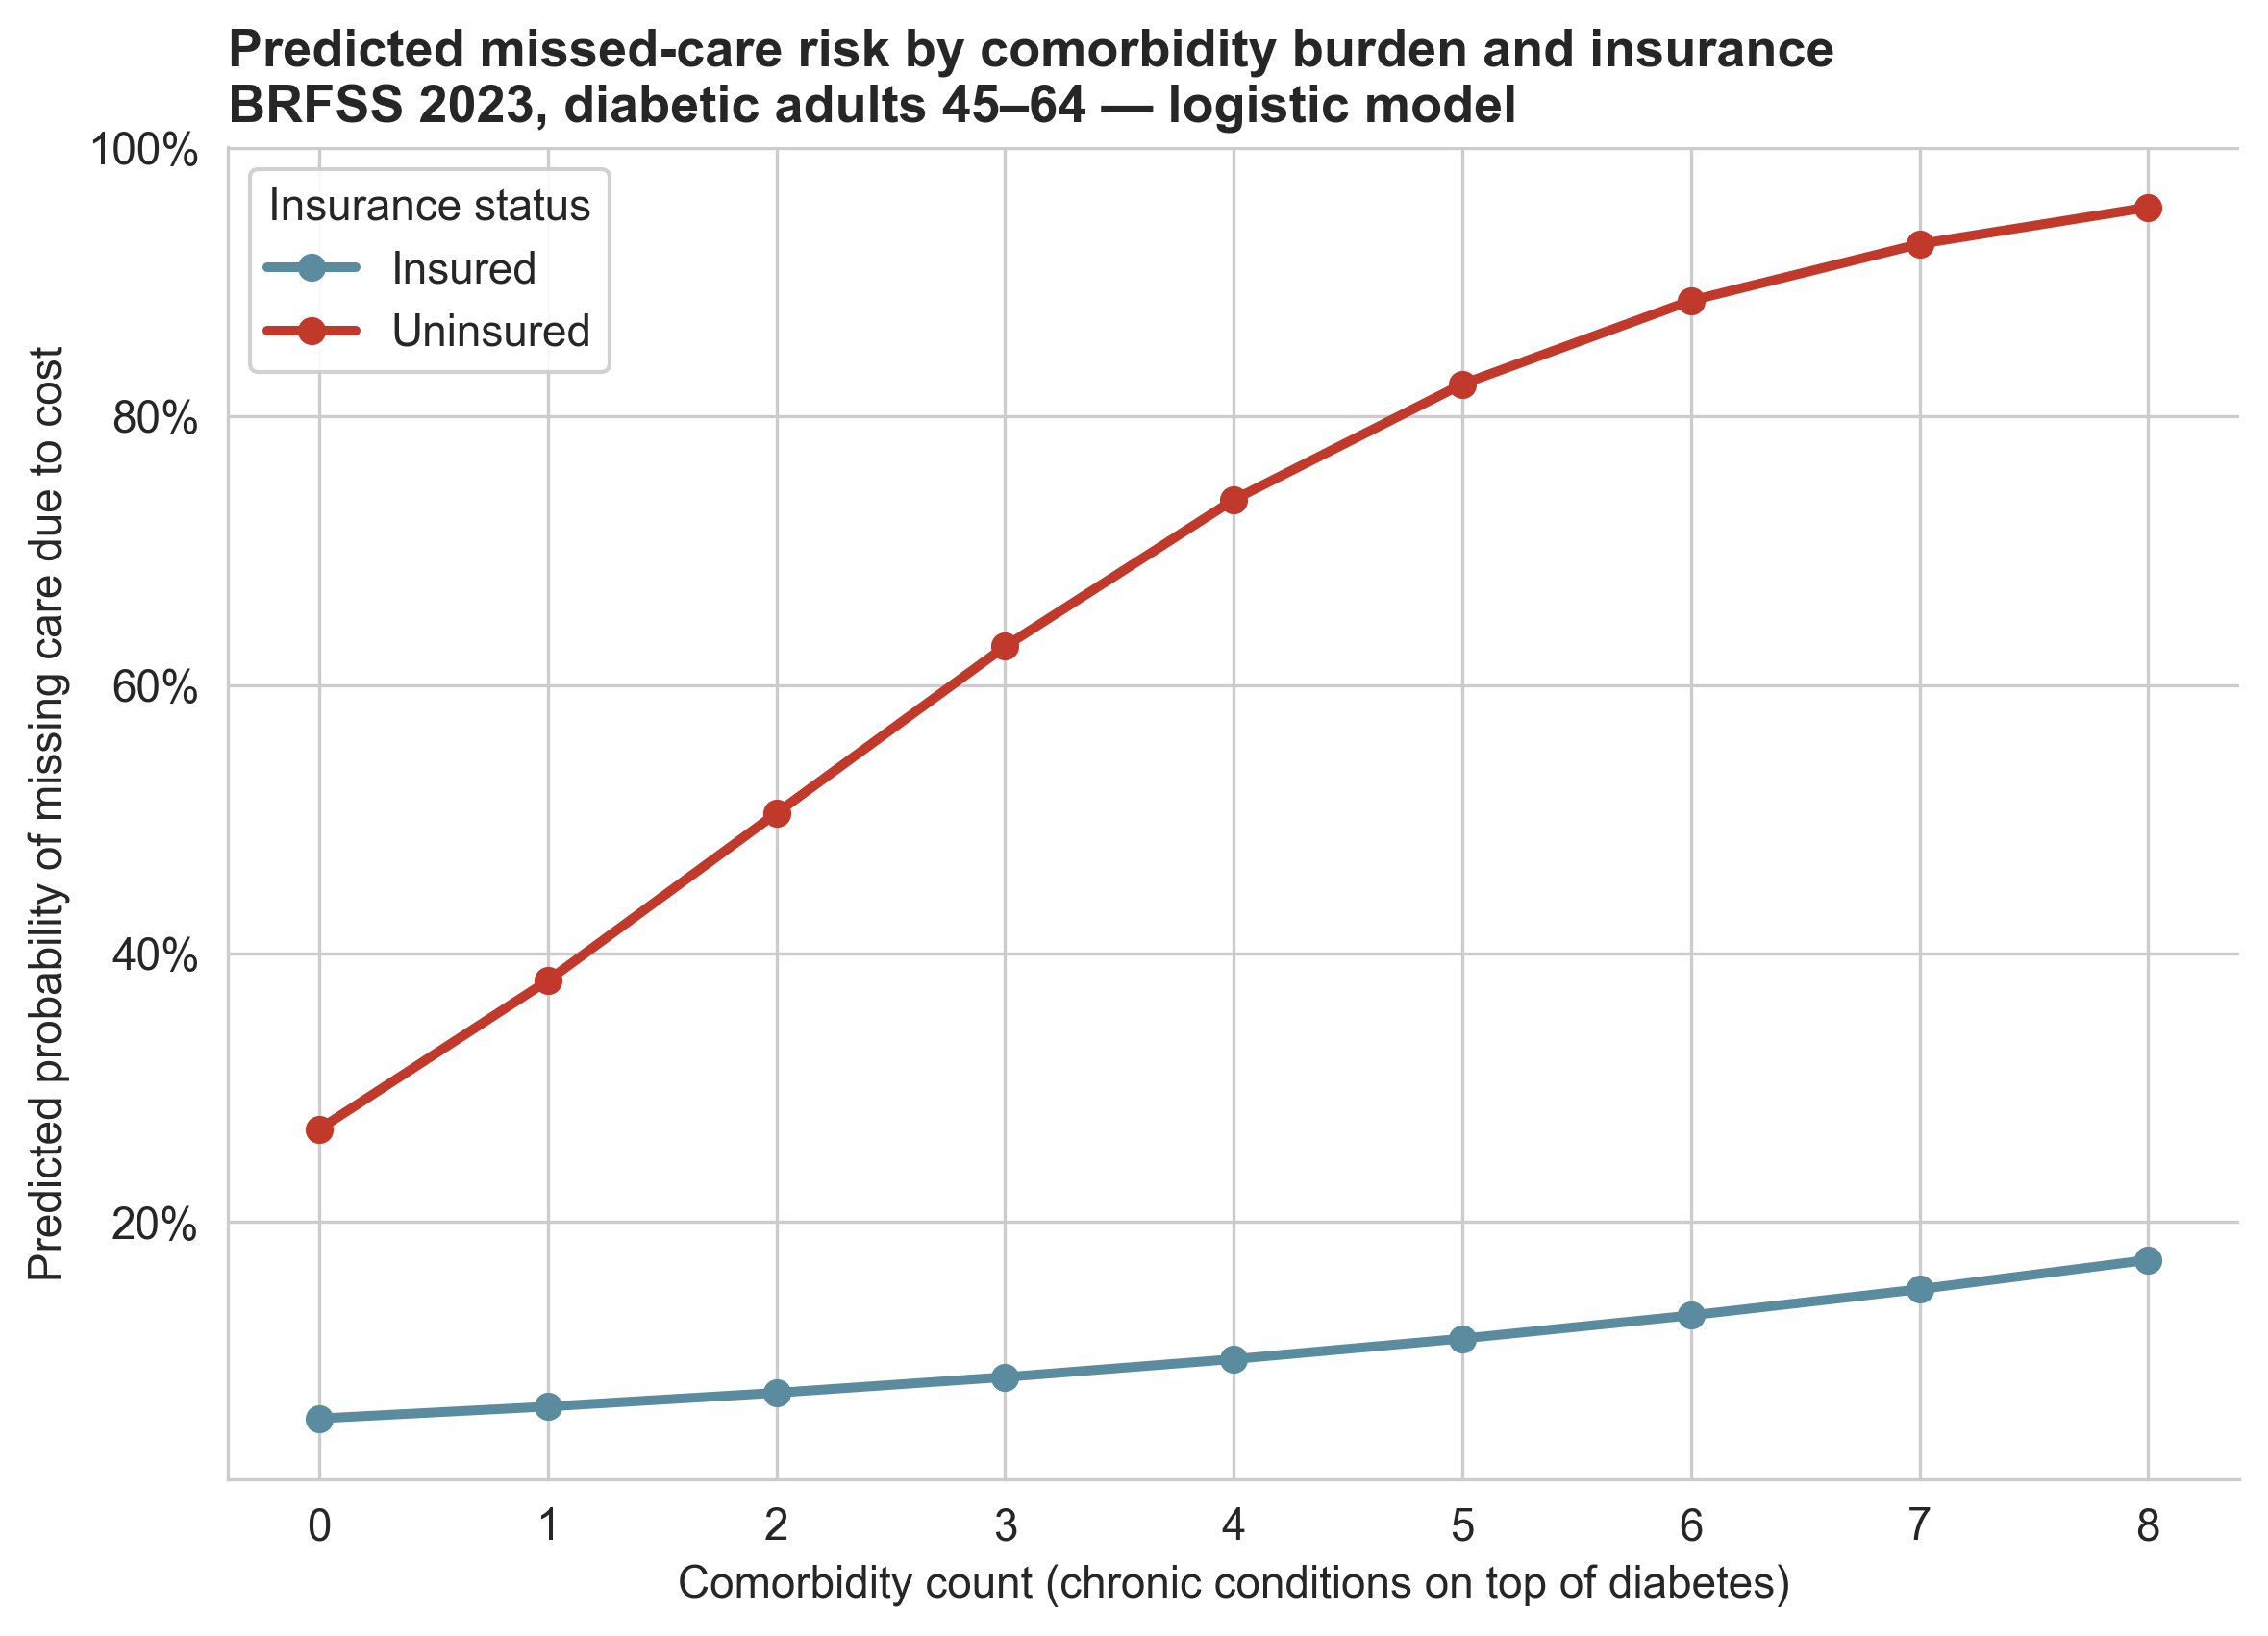

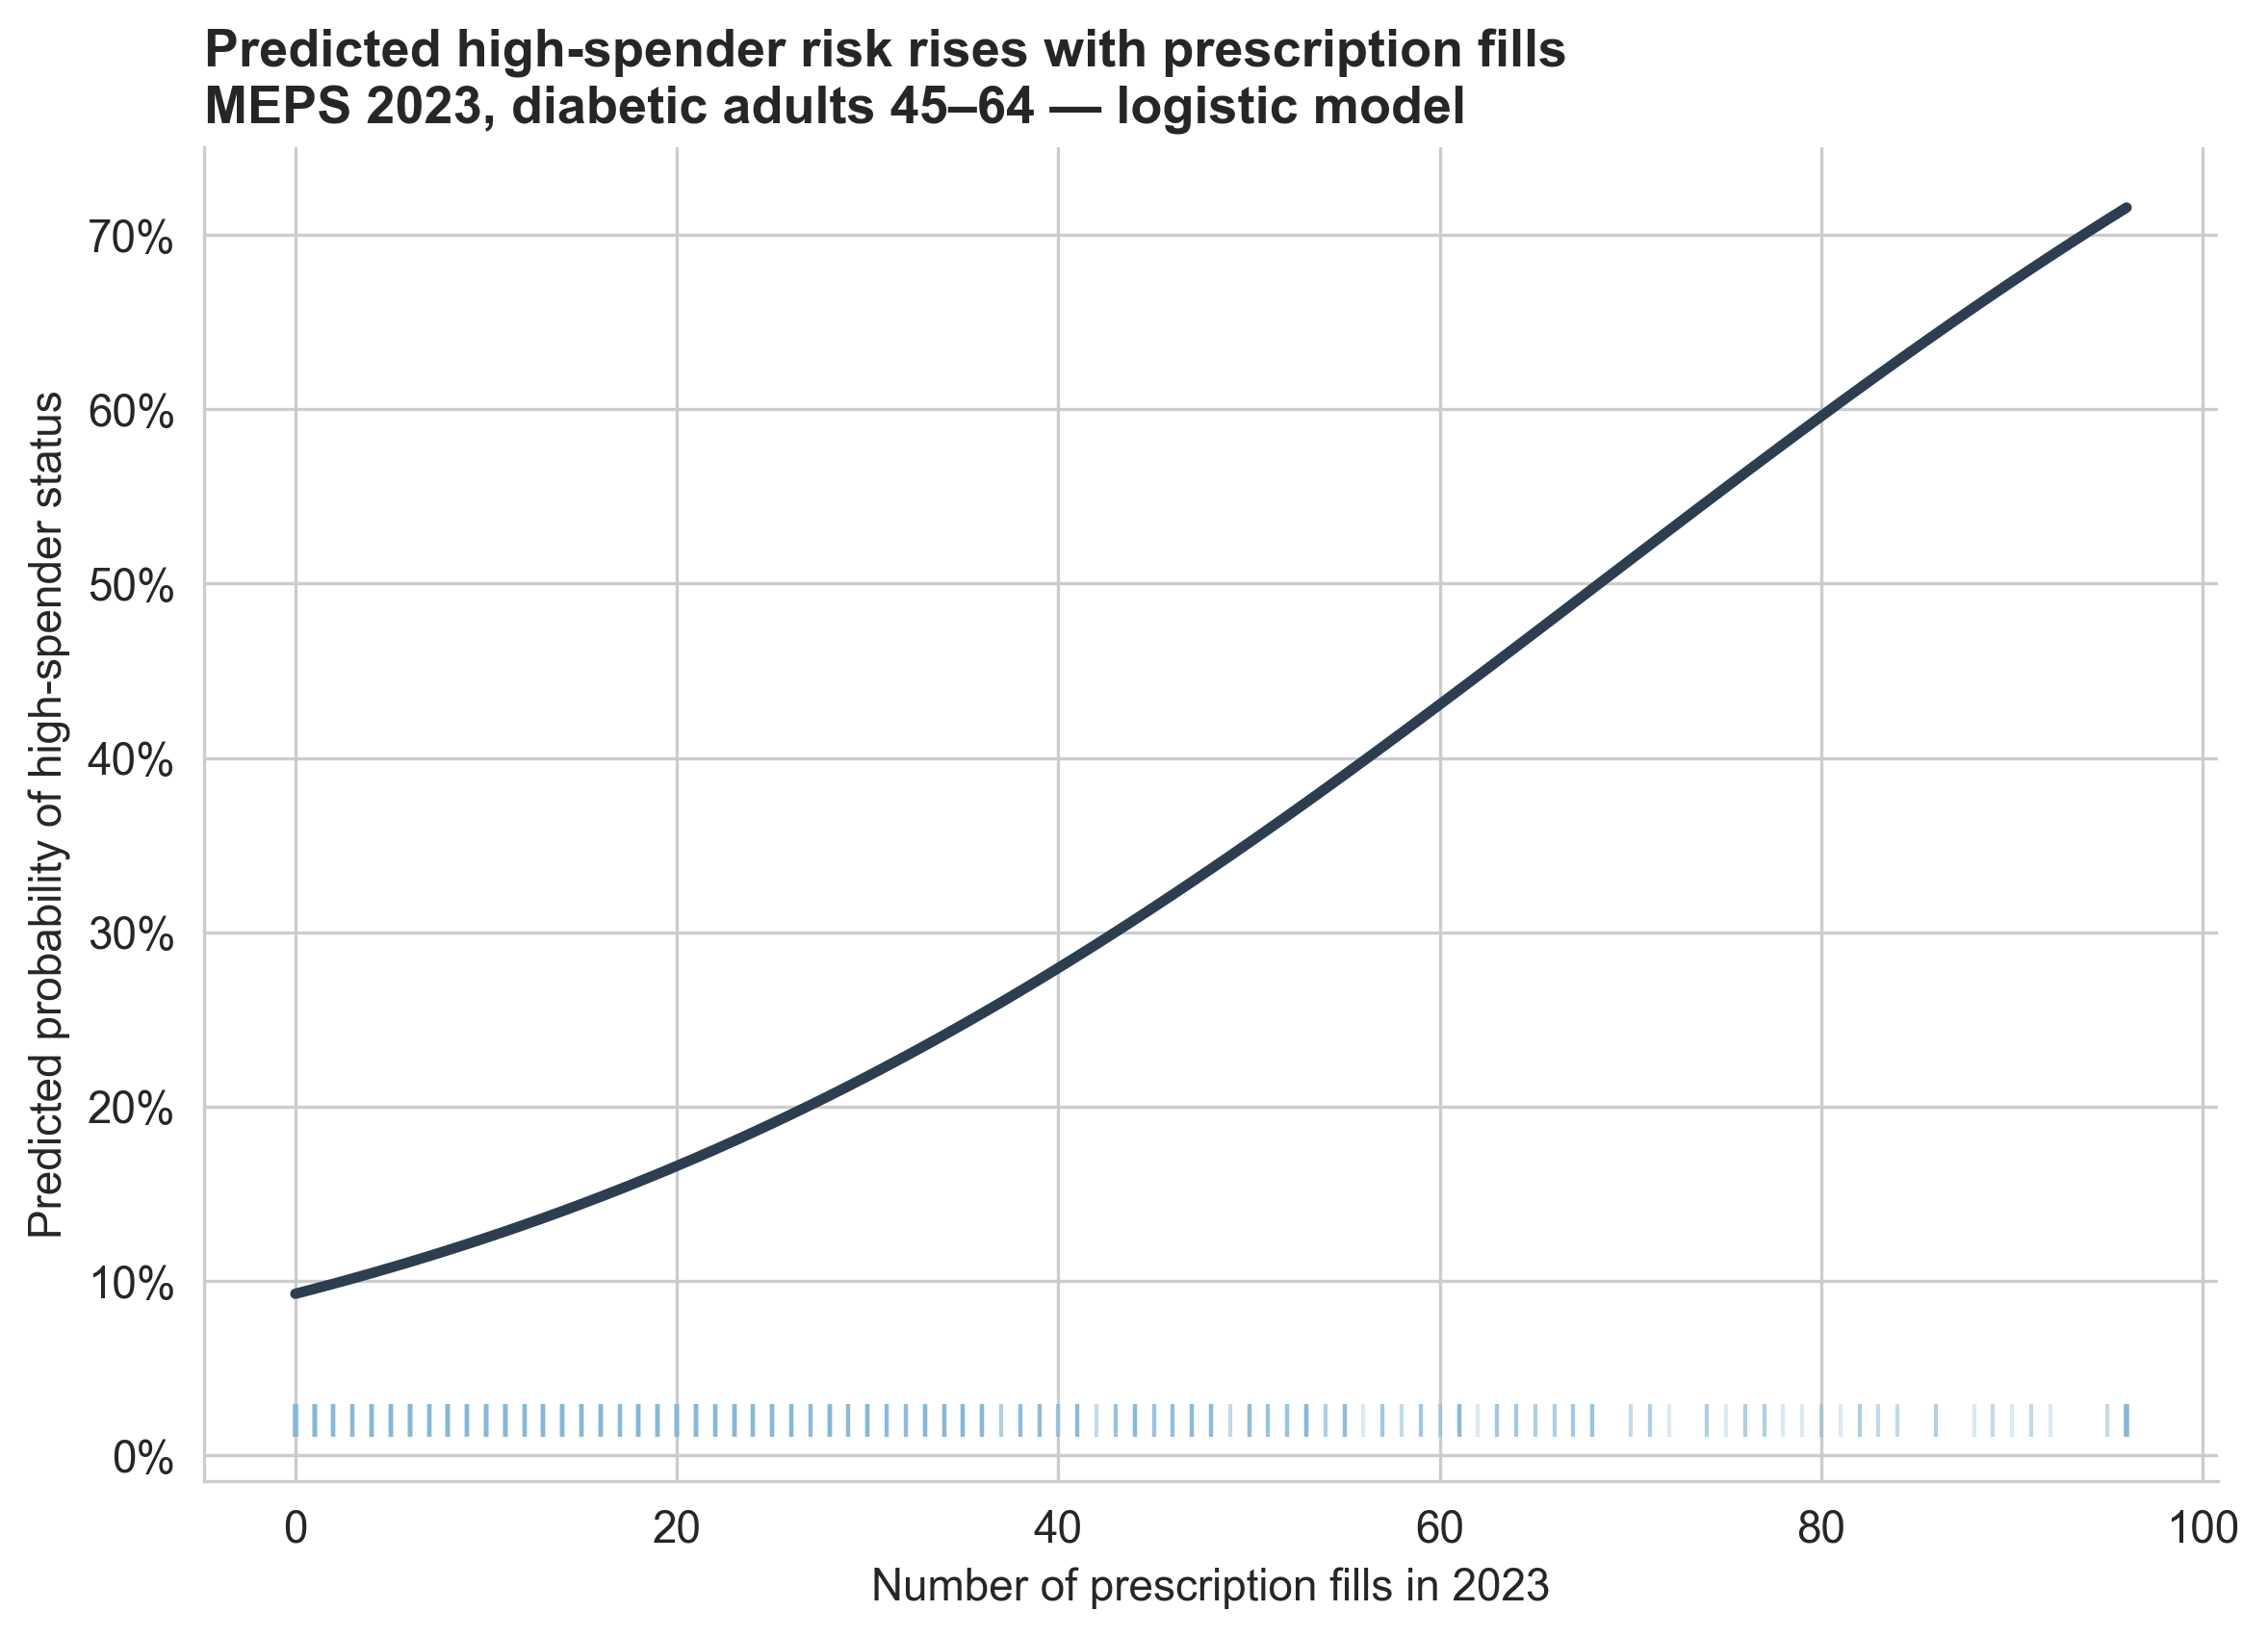

In [18]:
display(Image(filename="../outputs/figures/m2_curve_missed_care.png"))
display(Image(filename="../outputs/figures/m2_curve_high_spender.png"))

**Reading the curves.** For missed care, the insured line stays low and nearly flat (≈6%→17% across the comorbidity range) while the uninsured line climbs steeply (≈27%→96%) — the insurance gap *widens* as illness burden grows. For high spending, the predicted probability rises monotonically with prescription fills, from ≈10% at zero fills to ≈70% at the top of the observed range — quantifying why Rx fills is the dominant predictor.

## 9. Summary of Milestone 2 findings
- **Insurance is the key access barrier.** Uninsured diabetic adults have ~9× the *adjusted* odds and ~6× the risk of missing care due to cost; the effect survives full adjustment.
- **Income and health status add independent risk** (aOR ≈ 2.0 and ≈ 1.9).
- **State and socioeconomic context matter** — missed-care rates range from 6.0% (VT) to 12.6% (RI), and the lowest-income tier misses care ~4× as often as the highest.
- **The cost barrier is persistent (2019–2023)** and New England stays below the U.S. rate throughout (real BRFSS time-series).
- **High spending is driven by utilization, not insurance per se.** Prescription fills and inpatient stays dominate prediction (AUC ≈ 0.84); insurance loses significance once utilization is controlled.
- **Chosen methods for the final submission:** retain the multivariable **logistic regression** as the primary inferential model for missed care, and the **LASSO / logistic** classifier (with gradient boosting as a benchmark) as the predictive model for high-spender status.

All tables are exported to `outputs/tables/m2_*` and figures to `outputs/figures/m2_*`.

To regenerate everything from one call: `python -m src.milestone2_analysis` (or `m2.run_all()`).

In [19]:
# One-call reproduction of every table + figure in this workbook:
# results = m2.run_all()